# Stage 05a: Initial Model Training

**Purpose:** Quick validation with default hyperparameters

**Inputs:**
- data/04c_train_encoded.parquet
- data/04c_test_encoded.parquet
- config_generated/04c_monotonicity_constraints.yaml

**Outputs:**
- models/05a_model_initial.json
- results/05a_predictions_train.parquet
- results/05a_predictions_test.parquet
- results/05a_metrics.yaml

In [1]:
config_path = "config/car_coll/v1"

In [2]:
# Parameters
config_path = "config/car_comp/v1"


In [3]:
import matplotlib
matplotlib.use("Agg")

import pandas as pd
import numpy as np
import xgboost as xgb
import yaml, os, sys
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

sys.path.insert(0, str(Path.cwd() / "lib"))
from utils import setup_notebook_environment

print("########################################")
print("# STAGE 05a: INITIAL MODEL TRAINING")
print("########################################")

project_root = setup_notebook_environment()
from model_utils import inverse_transform, predict_with_transform, save_predictions
from data_preparation import prepare_model_data

########################################
# STAGE 05a: INITIAL MODEL TRAINING
########################################


In [4]:
print(f"Python: {sys.version}")
print(f"XGBoost: {xgb.__version__}")

Python: 3.11.15 (main, Jun 11 2026, 15:14:57) [Clang 20.1.8 ]
XGBoost: 3.1.1


In [5]:
# Get machine config
pc_num = open("current.pc").read().strip()
pc_id = f"PC{pc_num}"

config_file = f"{config_path}/config.yaml"
with open(config_file, "r") as f:
    cfg = yaml.safe_load(f)

output_base = cfg["machines"][pc_id]["paths"]["output_path"]
target = cfg["experiment"]["target"]
exposure = cfg["experiment"]["exposure"]
join_key = cfg["data"]["join_key"]
target_method = cfg["model"].get("target_method", "direct")
print(f"Target method: {target_method}")

Target method: residual


In [6]:
# Prepare data with loss cap filtering
loss_cap = cfg['experiment'].get('loss_cap', None)
loss_type = cfg['experiment'].get('loss_type', 'bi')
exposure_floor = cfg['experiment'].get('exposure_floor', None)

data = prepare_model_data(
    output_base=output_base,
    target_col=target,
    exposure_col=exposure,
    target_method=target_method,
    loss_cap=loss_cap,
    
    loss_type=loss_type,
    exposure_floor=exposure_floor,
    verbose=True
)

# Extract prepared data
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
w_train = data['w_train']
w_test = data['w_test']
pp_train_actual = data['pp_train']
pp_test_actual = data['pp_test']
glm_train = data['glm_train']
glm_test = data['glm_test']
train_orig = data['train_orig']
test_orig = data['test_orig']
top_100_report = data['top_100_report']

# Save top 100 report if generated
if top_100_report is not None:
    report_path = f"{output_base}/reports"
    import os
    os.makedirs(report_path, exist_ok=True)
    top_100_report.to_csv(f"{report_path}/top_100_targets_before_cap.csv", index=True)
    print(f"  Saved top 100 report to: {report_path}/top_100_targets_before_cap.csv")

print(f"  Train: {X_train.shape}")
print(f"  Test: {X_test.shape}")
print(f"  Features: {X_train.shape[1]}")
# Diagnostic: Target statistics
if isinstance(y_train, np.ndarray):
    y_train_arr = y_train
    y_test_arr = y_test
else:
    y_train_arr = y_train.values
    y_test_arr = y_test.values

print(f"\n* Target (y) statistics:")
print(f"  y_train: mean={y_train_arr.mean():.4f}, std={y_train_arr.std():.4f}, min={y_train_arr.min():.4f}, max={y_train_arr.max():.4f}")
print(f"  y_test:  mean={y_test_arr.mean():.4f}, std={y_test_arr.std():.4f}, min={y_test_arr.min():.4f}, max={y_test_arr.max():.4f}")



PREPARING MODEL DATA

* Loading encoded features...


  Loaded - Train: 4,550,028, Test: 4,539,000

* Loading GLM predictions...


  Removed NaN GLM predictions:
    Train: 1,129,793 (25.73%)
    Test: 1,128,988 (25.78%)


  Rows without valid GLM:
    Train: 1,288,027 (28.31%)
    Test: 1,288,728 (28.39%)


  GLM loaded: train=3,262,001, test=3,250,272

* Transforming target (method: residual)...

* Final dataset sizes:
  Train: 3,262,001 records x 197 features
  Test: 3,250,272 records x 197 features

  Train: (3262001, 197)
  Test: (3250272, 197)
  Features: 197

* Target (y) statistics:


  y_train: mean=1.5127, std=240.0852, min=0.0000, max=416357.6708
  y_test:  mean=1.4835, std=91.1979, min=0.0000, max=95108.3698


In [7]:
# Load monotonicity constraints
mono_file = f"{output_base}/config_generated/04c_monotonicity_constraints.yaml"
if os.path.exists(mono_file):
    print(f"\n* Loading monotonicity constraints...")
    with open(mono_file, "r") as f:
        mono_dict = yaml.safe_load(f)
    # Build constraints tuple in feature order
    feature_names = X_train.columns.tolist()
    monotone_constraints = tuple(mono_dict.get(f, 0) for f in feature_names)
    n_constrained = sum(1 for c in monotone_constraints if c != 0)
    print(f"  Loaded {n_constrained} constraints")
else:
    monotone_constraints = None
    print(f"\n* No monotonicity constraints found")


* Loading monotonicity constraints...
  Loaded 9 constraints


In [8]:
# Build XGBoost parameters
print(f"\n* Building XGBoost parameters...")
xgb_params = cfg["xgboost"].copy()
n_estimators = xgb_params.pop("n_estimators")

# Add monotonicity constraints if available
if monotone_constraints:
    xgb_params["monotone_constraints"] = monotone_constraints

# Fix eval_metric for tweedie
if "eval_metric" in xgb_params and "tweedie" in xgb_params["eval_metric"]:
    if "@" not in xgb_params["eval_metric"]:
        variance_power = xgb_params["tweedie_variance_power"]
        xgb_params["eval_metric"] = f"{xgb_params['eval_metric']}@{variance_power}"

print(f"  n_estimators: {n_estimators}")
print(f"  monotone_constraints: {monotone_constraints is not None}")


* Building XGBoost parameters...
  n_estimators: 500
  monotone_constraints: True


In [9]:
# Train model
print(f"\n* Training XGBoost model...")

model = xgb.XGBRegressor(n_estimators=n_estimators, **xgb_params)

model.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    sample_weight_eval_set=[w_train, w_test],
    verbose=100
)

print(f"\n* Training complete")
print(f"  Best iteration: {model.best_iteration}")


* Training XGBoost model...


[0]	validation_0-tweedie-nloglik@1.5:3.97345	validation_1-tweedie-nloglik@1.5:3.99477


[100]	validation_0-tweedie-nloglik@1.5:3.89822	validation_1-tweedie-nloglik@1.5:3.94001


[200]	validation_0-tweedie-nloglik@1.5:3.88045	validation_1-tweedie-nloglik@1.5:3.93425


[300]	validation_0-tweedie-nloglik@1.5:3.86863	validation_1-tweedie-nloglik@1.5:3.93374


[323]	validation_0-tweedie-nloglik@1.5:3.86629	validation_1-tweedie-nloglik@1.5:3.93389



* Training complete
  Best iteration: 274


In [10]:
# Generate predictions
print(f"\n* Generating predictions...")
# Generate predictions with inverse transform
gbm_train_raw, pred_train = predict_with_transform(model, X_train, glm_train, target_method)
gbm_test_raw, pred_test = predict_with_transform(model, X_test, glm_test, target_method)

print(f"  Predictions: train mean={pred_train.mean():.2f}, test mean={pred_test.mean():.2f}")

# Calculate metrics
mae_train = mean_absolute_error(pp_train_actual, pred_train, sample_weight=w_train)
mae_test = mean_absolute_error(pp_test_actual, pred_test, sample_weight=w_test)
rmse_train = np.sqrt(mean_squared_error(pp_train_actual, pred_train, sample_weight=w_train))
rmse_test = np.sqrt(mean_squared_error(pp_test_actual, pred_test, sample_weight=w_test))

print(f"\n* Metrics:")
print(f"  Train MAE: {mae_train:.4f}, RMSE: {rmse_train:.4f}")
print(f"  Test MAE: {mae_test:.4f}, RMSE: {rmse_test:.4f}")


* Generating predictions...


  Predictions: train mean=152.54, test mean=152.66



* Metrics:
  Train MAE: 288.7714, RMSE: 3202.0405
  Test MAE: 288.6143, RMSE: 3153.5198


In [11]:
# Prepare data for lift charts
import matplotlib.pyplot as plt
from lift_chart_fast import create_lift_chart
from hpo_metrics import compute_fit_quality, compute_model_power
from IPython.display import Image, display

print(f'\n* Preparing lift chart data...')

# Add predictions
train_orig['pred'] = pred_train.values if isinstance(pred_train, pd.Series) else pred_train
test_orig['pred'] = pred_test.values if isinstance(pred_test, pd.Series) else pred_test

# Create incurred columns (pp * ee = capped loss)
train_orig['incurred_act'] = (pp_train_actual if isinstance(pp_train_actual, np.ndarray) else pp_train_actual.values) * w_train
train_orig['incurred_pred'] = (pred_train.values if isinstance(pred_train, pd.Series) else pred_train) * w_train
train_orig['denom'] = 1

test_orig['incurred_act'] = (pp_test_actual if isinstance(pp_test_actual, np.ndarray) else pp_test_actual.values) * w_test
test_orig['incurred_pred'] = (pred_test.values if isinstance(pred_test, pd.Series) else pred_test) * w_test
test_orig['denom'] = 1

# GBM-only columns (to see pure GBM effect - ratios)
train_orig['incurred_act_gbm'] = (y_train if isinstance(y_train, np.ndarray) else y_train.values) * w_train
train_orig['incurred_pred_gbm'] = (gbm_train_raw.values if isinstance(gbm_train_raw, pd.Series) else gbm_train_raw) * w_train

test_orig['incurred_act_gbm'] = (y_test if isinstance(y_test, np.ndarray) else y_test.values) * w_test
test_orig['incurred_pred_gbm'] = (gbm_test_raw.values if isinstance(gbm_test_raw, pd.Series) else gbm_test_raw) * w_test

print(f'  Data prepared (incurred = pp * ee = capped loss)')



* Preparing lift chart data...
  Data prepared (incurred = pp * ee = capped loss)



* Creating train lift chart...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 7 columns from 3,262,001 rows...
  [STEP 2] Done in 0.048s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.5s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.017s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.163s
  Creating plot...


  Plot created in 0.0s
  TOTAL TIME: 0.8s
  Saved: output/car_comp/v1/results/05a_lift_train.png


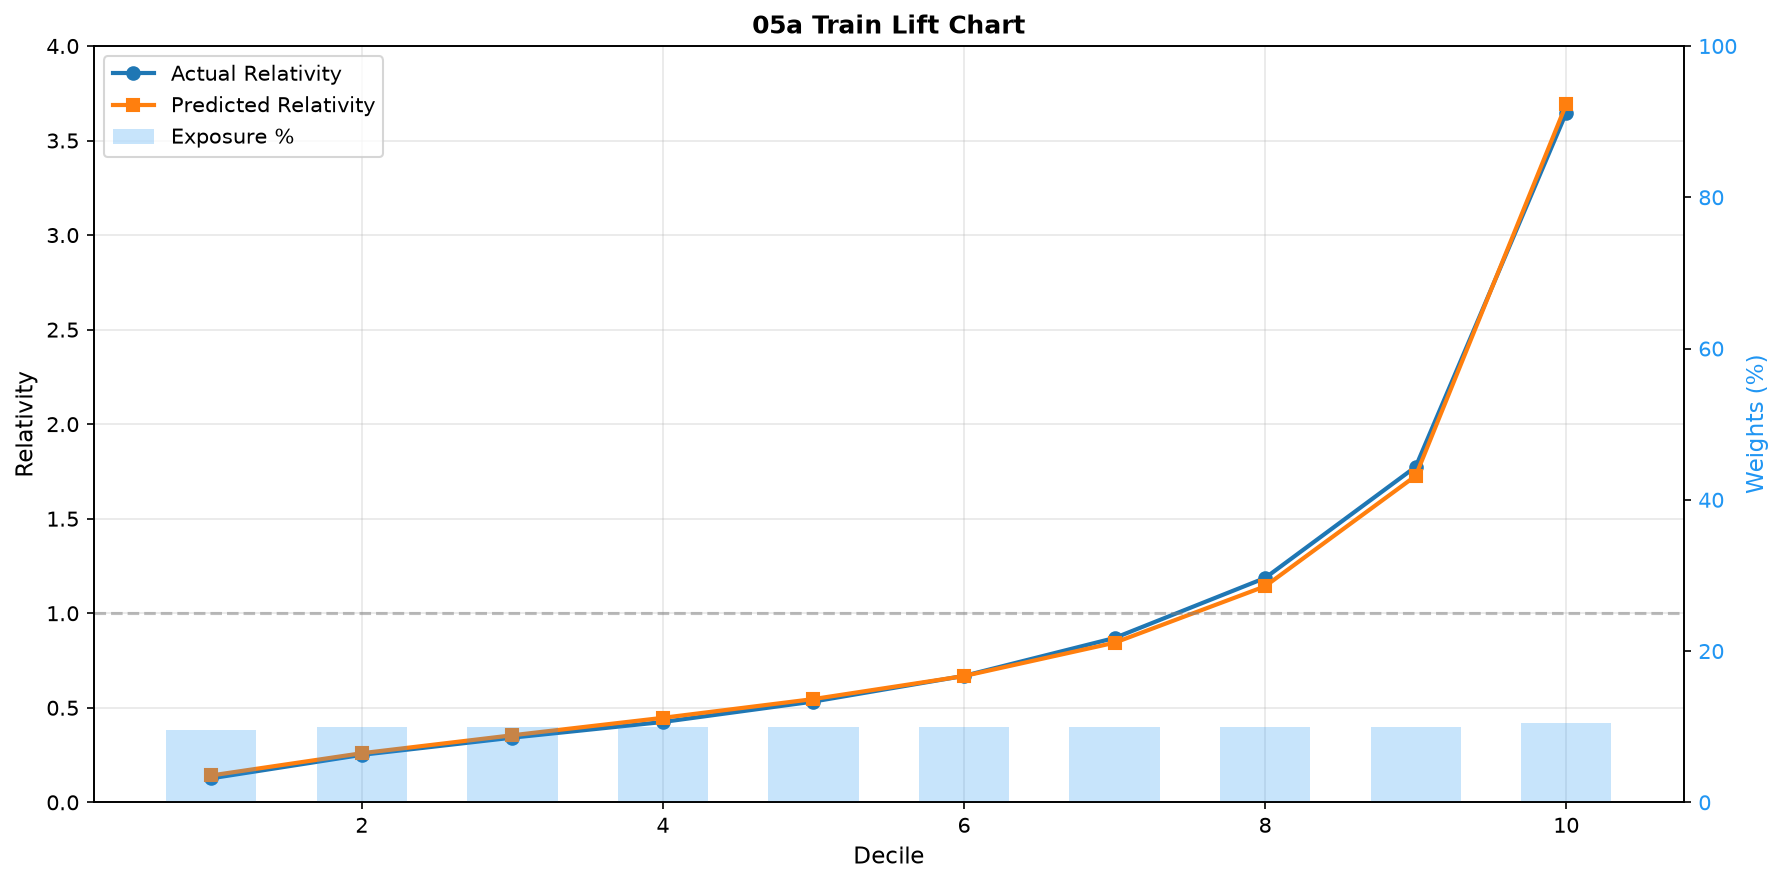


Train decile summary:
 decile  n_records  ee_comp_imps  incurred_act  incurred_pred  act_ee_weigh_avg  act_simple_avg  pred_ee_weigh_avg  pred_simple_avg
      1     291422 205173.067557    3946458.88   4.413739e+06         19.234780       13.542076          21.512274        15.145525
      2     309730 215971.862961    8213237.65   8.493914e+06         38.029202       26.517411          39.328801        27.423609
      3     312757 215971.410607   11184090.86   1.159631e+07         51.785053       35.759682          53.693737        37.077706
      4     316947 215972.198593   13897279.79   1.461483e+07         64.347540       43.847330          67.669967        46.111279
      5     325731 215972.067707   17428926.41   1.785797e+07         80.699910       53.507116          82.686482        54.824289
      6     336426 215972.122726   21865111.77   2.184075e+07        101.240436       64.992336         101.127654        64.919935
      7     346354 215971.051583   28420903.19   2.75

In [12]:
# Train lift chart
print(f'\n* Creating train lift chart...')
fig_train, table_train = create_lift_chart(
    train_orig, 
    exposure,  # weight column for decile binning
    bins=10, 
    title='05a Train Lift Chart'
)

chart_file = f'{output_base}/results/05a_lift_train.png'
fig_train.savefig(chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_train)
print(f'  Saved: {chart_file}')

display(Image(chart_file))
print('\nTrain decile summary:')
print(table_train[['decile', 'n_records', exposure, 'incurred_act', 'incurred_pred', 'act_ee_weigh_avg', 'act_simple_avg', 'pred_ee_weigh_avg', 'pred_simple_avg']].to_string(index=False))
table_train.to_csv(f"{output_base}/results/05a_lift_train_table.csv", index=False)



* Creating test lift chart...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 7 columns from 3,250,272 rows...
  [STEP 2] Done in 0.025s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.5s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.024s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.164s
  Creating plot...


  Plot created in 0.0s
  TOTAL TIME: 0.7s
  Saved: output/car_comp/v1/results/05a_lift_test.png


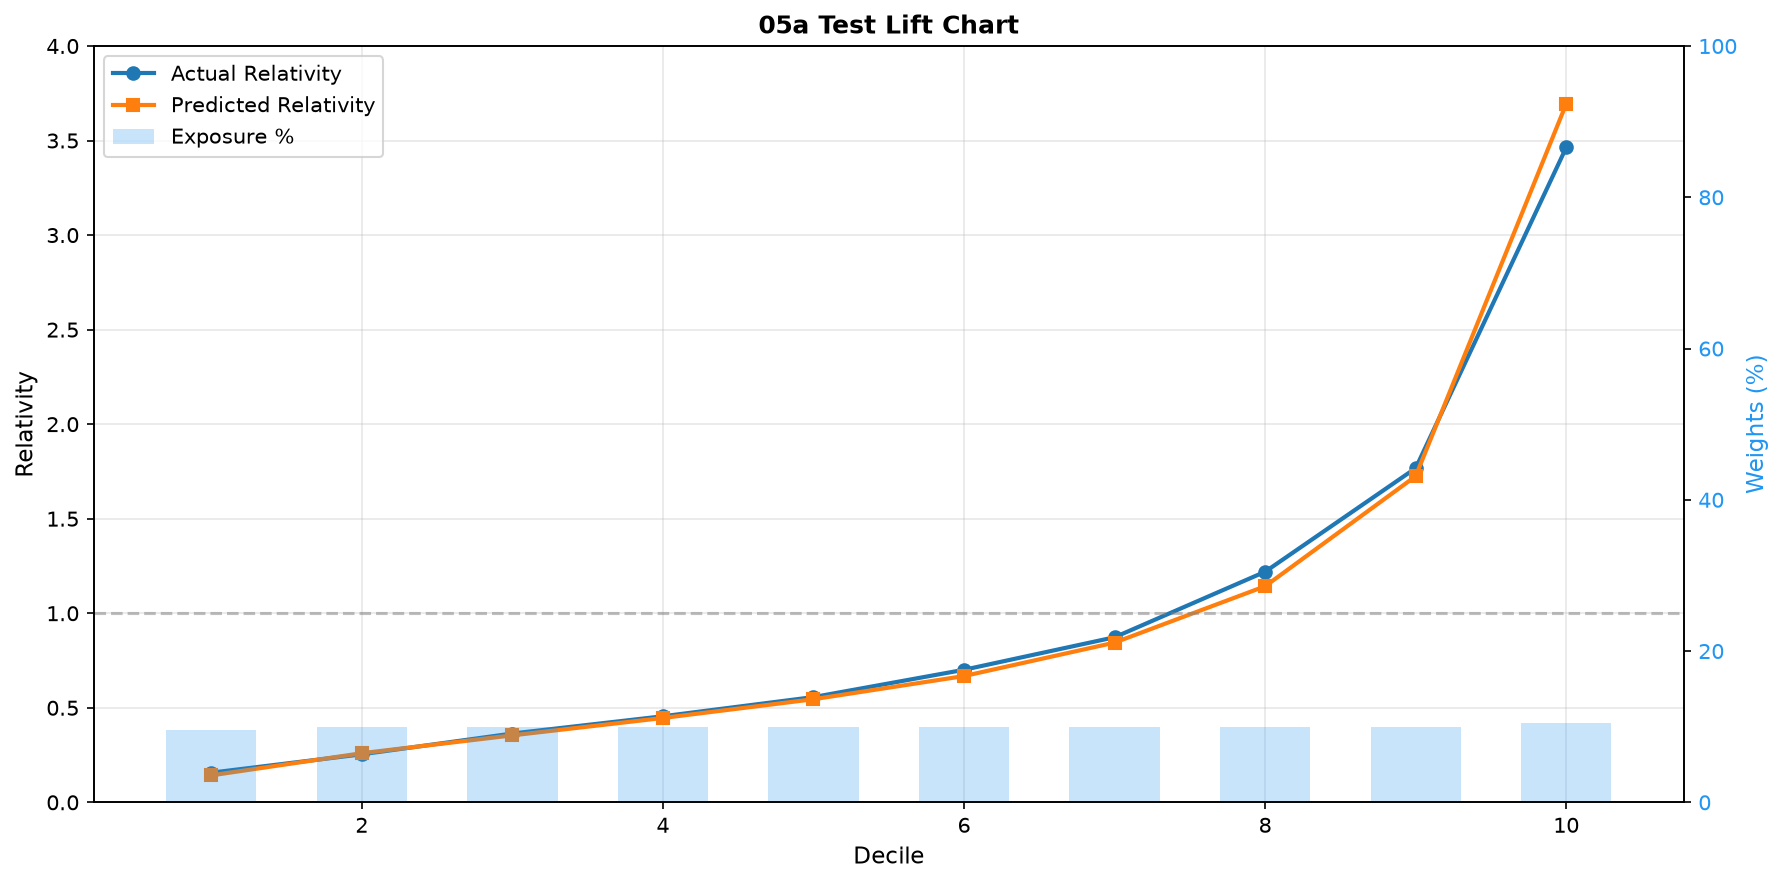


Test decile summary:
 decile  n_records  ee_comp_imps  incurred_act  incurred_pred  act_ee_weigh_avg  act_simple_avg  pred_ee_weigh_avg  pred_simple_avg
      1     289912 204212.856920    4852288.26   4.409808e+06         23.760934       16.737107          21.594173        15.210850
      2     308956 214960.775537    8272436.72   8.457980e+06         38.483471       26.775453          39.346620        27.376002
      3     311237 214961.218819   11847871.33   1.153569e+07         55.116320       38.067040          53.664051        37.064006
      4     315948 214961.984490   14817838.40   1.452623e+07         68.932367       46.899611          67.575830        45.976662
      5     324415 214961.422419   18121853.05   1.775370e+07         84.302815       55.860096          82.590155        54.725266
      6     334843 214960.850004   22823019.76   2.174163e+07        106.172914       68.160361         101.142258        64.930805
      7     344970 214961.247840   28422278.64   2.750

In [13]:
# Test lift chart
print(f'\n* Creating test lift chart...')
fig_test, table_test = create_lift_chart(
    test_orig, 
    exposure,  # weight column for decile binning
    bins=10, 
    title='05a Test Lift Chart'
)

chart_file = f'{output_base}/results/05a_lift_test.png'
fig_test.savefig(chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_test)
print(f'  Saved: {chart_file}')

display(Image(chart_file))
print('\nTest decile summary:')
print(table_test[['decile', 'n_records', exposure, 'incurred_act', 'incurred_pred', 'act_ee_weigh_avg', 'act_simple_avg', 'pred_ee_weigh_avg', 'pred_simple_avg']].to_string(index=False))
table_test.to_csv(f"{output_base}/results/05a_lift_test_table.csv", index=False)



* Creating ratio lift charts...


  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 7 columns from 3,262,001 rows...
  [STEP 2] Done in 0.030s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.5s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.014s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.160s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 0.7s


  Saved: output/car_comp/v1/results/05a_lift_train_ratio.png


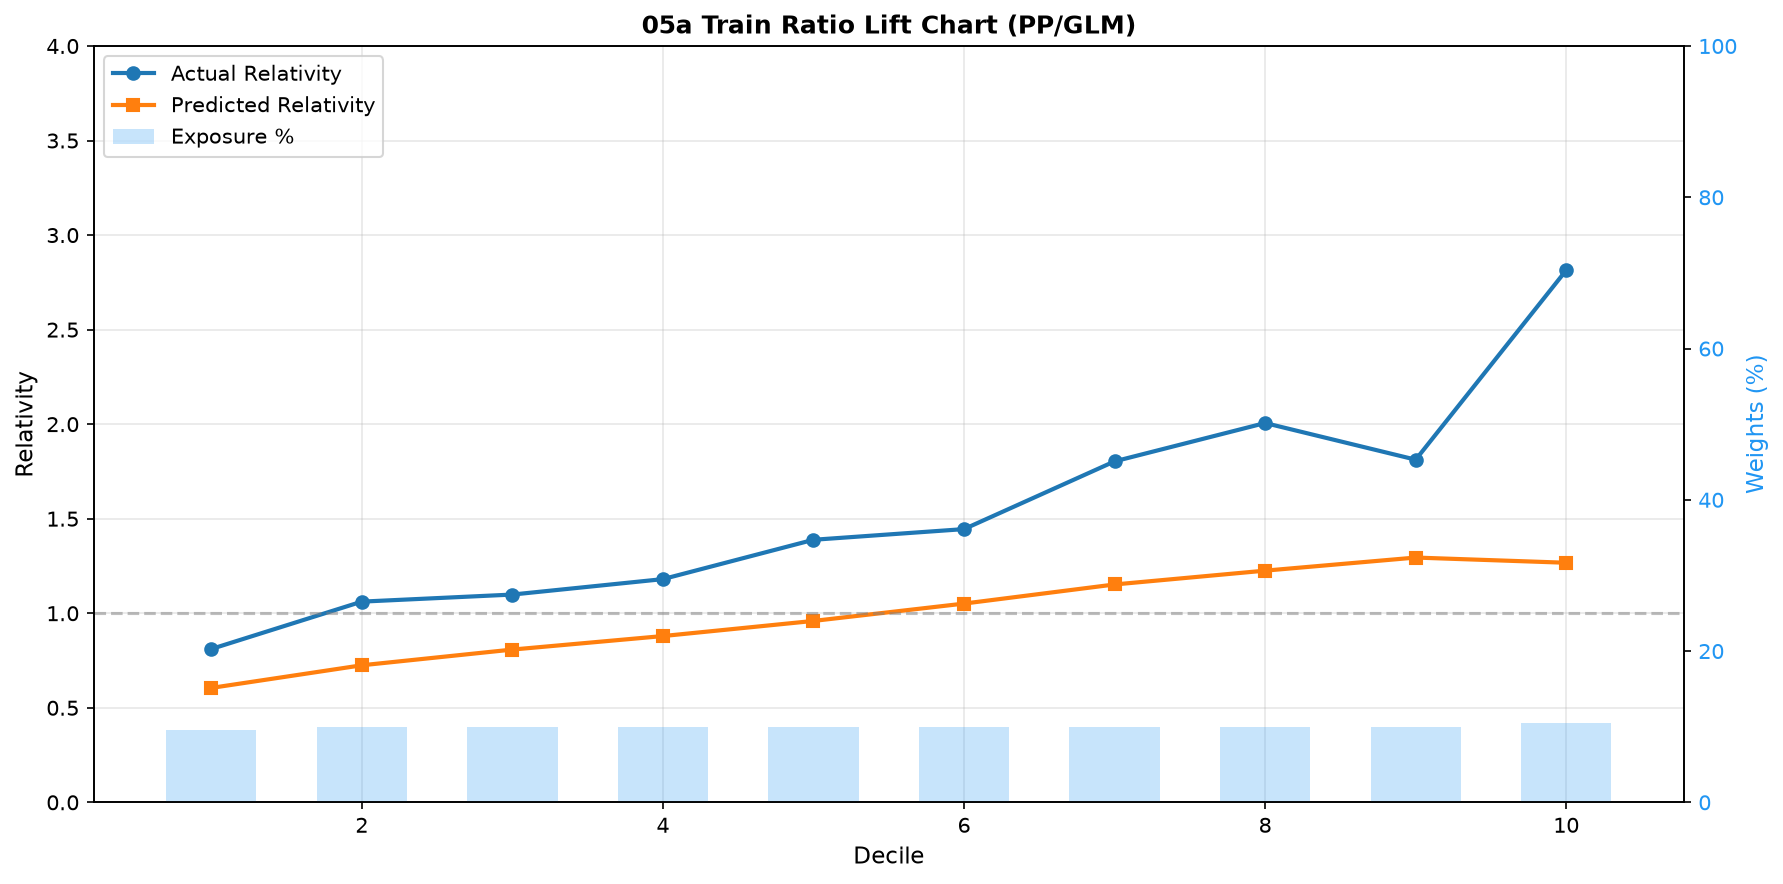


Train ratio summary:
 decile  n_records  ee_comp_imps  incurred_act  incurred_pred  act_ee_weigh_avg  act_simple_avg  pred_ee_weigh_avg  pred_simple_avg
      1     291422 205173.067557 244906.548858  182743.250000          1.193658        0.840385           0.890679         0.627074
      2     309730 215971.862961 337470.057254  230434.828125          1.562565        1.089562           1.066967         0.743986
      3     312757 215971.410607 349342.627111  256851.437500          1.617541        1.116978           1.189284         0.821249
      4     316947 215972.198593 375295.401256  279578.437500          1.737702        1.184095           1.294511         0.882098
      5     325731 215972.067707 441460.402187  305011.468750          2.044062        1.355291           1.412273         0.936391
      6     336426 215972.122726 459391.744308  334169.218750          2.127088        1.365506           1.547279         0.993292
      7     346354 215971.051583 573289.247700  366313

  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 7 columns from 3,250,272 rows...
  [STEP 2] Done in 0.028s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.5s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.014s
  [STEP 5] Aggregating by decile...
  [STEP 5] Done in 0.162s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 0.7s


  Saved: output/car_comp/v1/results/05a_lift_test_ratio.png


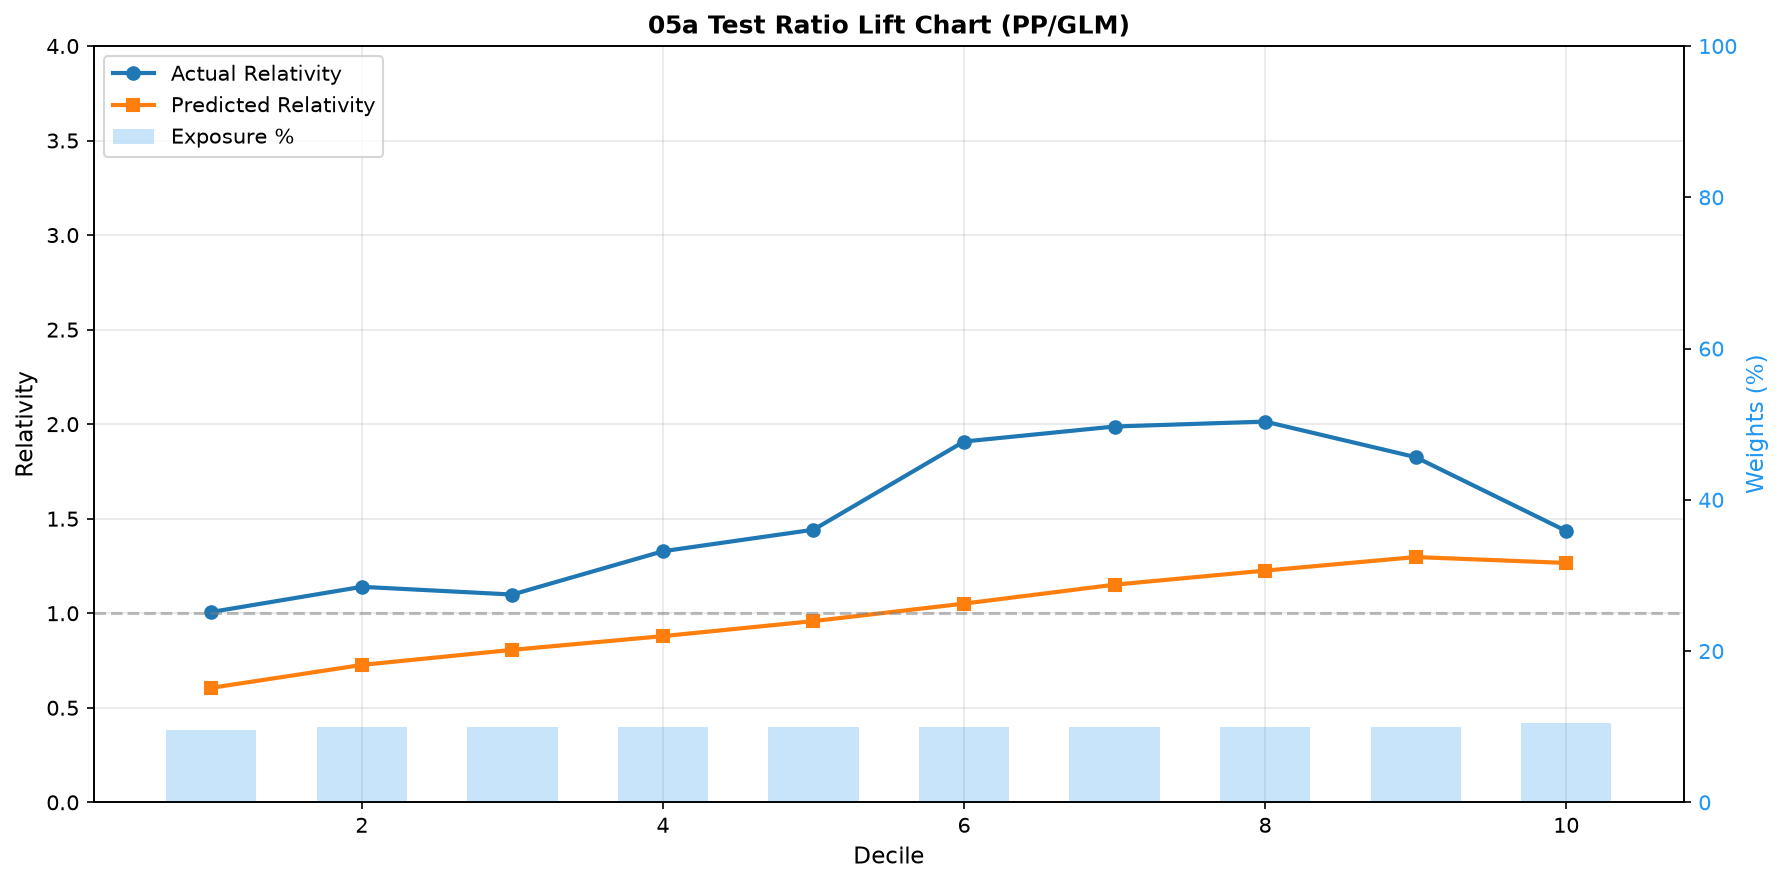


Test ratio summary:
 decile  n_records  ee_comp_imps  incurred_act  incurred_pred  act_ee_weigh_avg  act_simple_avg  pred_ee_weigh_avg  pred_simple_avg
      1     289912 204212.856920 303216.021707  182420.515625          1.484804        1.045890           0.893286         0.629227
      2     308956 214960.775537 361394.195911  230423.890625          1.681210        1.169727           1.071935         0.745815
      3     311237 214961.218819 348477.273811  255695.578125          1.621117        1.119652           1.189496         0.821546
      4     315948 214961.984490 421071.831844  278721.031250          1.958820        1.332725           1.296606         0.882174
      5     324415 214961.422419 457175.189751  303942.906250          2.126778        1.409230           1.413942         0.936895
      6     334843 214960.850004 605081.924964  333248.500000          2.814847        1.807062           1.550275         0.995238
      7     344970 214961.247840 630245.154173  365006.

In [14]:
# Ratio lift charts (for residual method only)
if target_method == 'residual':
    print(f'\n* Creating ratio lift charts...')
    
    # Train ratio chart
    train_ratio = train_orig.copy()
    train_ratio['incurred_act'] = y_train if isinstance(y_train, np.ndarray) else y_train.values
    train_ratio['incurred_pred'] = gbm_train_raw.values if isinstance(gbm_train_raw, pd.Series) else gbm_train_raw
    train_ratio['denom'] = 1
    
    fig_train_r, table_train_r = create_lift_chart(
        train_ratio, exposure, bins=10,
        title='05a Train Ratio Lift Chart (PP/GLM)'
    )
    chart_file = f'{output_base}/results/05a_lift_train_ratio.png'
    fig_train_r.savefig(chart_file, dpi=150, bbox_inches='tight')
    plt.close(fig_train_r)
    print(f'  Saved: {chart_file}')
    display(Image(chart_file))
    print('\nTrain ratio summary:')
    print(table_train_r[['decile', 'n_records', exposure, 'incurred_act', 'incurred_pred', 'act_ee_weigh_avg', 'act_simple_avg', 'pred_ee_weigh_avg', 'pred_simple_avg']].to_string(index=False))
    table_train_r.to_csv(f"{output_base}/results/05a_lift_train_ratio_table.csv", index=False)
    
    # Test ratio chart
    test_ratio = test_orig.copy()
    test_ratio['incurred_act'] = y_test if isinstance(y_test, np.ndarray) else y_test.values
    test_ratio['incurred_pred'] = gbm_test_raw.values if isinstance(gbm_test_raw, pd.Series) else gbm_test_raw
    test_ratio['denom'] = 1
    
    fig_test_r, table_test_r = create_lift_chart(
        test_ratio, exposure, bins=10,
        title='05a Test Ratio Lift Chart (PP/GLM)'
    )
    chart_file = f'{output_base}/results/05a_lift_test_ratio.png'
    fig_test_r.savefig(chart_file, dpi=150, bbox_inches='tight')
    plt.close(fig_test_r)
    print(f'  Saved: {chart_file}')
    display(Image(chart_file))
    print('\nTest ratio summary:')
    print(table_test_r[['decile', 'n_records', exposure, 'incurred_act', 'incurred_pred', 'act_ee_weigh_avg', 'act_simple_avg', 'pred_ee_weigh_avg', 'pred_simple_avg']].to_string(index=False))
    table_test_r.to_csv(f"{output_base}/results/05a_lift_test_ratio_table.csv", index=False)
else:
    print(f'\n* Skipping ratio charts (direct method)')


In [15]:
# Calculate actuarial metrics
print(f'\n* Calculating actuarial metrics...')

fit_train = compute_fit_quality(pp_train_actual, pred_train, w_train)
fit_test = compute_fit_quality(pp_test_actual, pred_test, w_test)
power_train = compute_model_power(pp_train_actual, pred_train, w_train)
power_test = compute_model_power(pp_test_actual, pred_test, w_test)

print(f'\n* Actuarial Metrics:')
print(f'  Train:')
print(f'    Fit Quality:  {fit_train:.4f}')
print(f'    Model Power:  {power_train:.4f}')
print(f'  Test:')
print(f'    Fit Quality:  {fit_test:.4f}')
print(f'    Model Power:  {power_test:.4f}')


* Calculating actuarial metrics...



* Actuarial Metrics:
  Train:
    Fit Quality:  0.9633
    Model Power:  0.7390
  Test:
    Fit Quality:  0.9588
    Model Power:  0.7401


In [16]:
# Save model
os.makedirs(f"{output_base}/models", exist_ok=True)
model_file = f"{output_base}/models/05a_model_initial.json"
model.get_booster().save_model(model_file)
print(f"\n* Saved model: {model_file}")


* Saved model: output/car_comp/v1/models/05a_model_initial.json


In [17]:
# Save predictions using utility function
print(f"\n* Saving predictions...")
save_predictions(output_base, "05a", "train", pp_train_actual, pred_train, w_train, index=train_orig.index)
save_predictions(output_base, "05a", "test", pp_test_actual, pred_test, w_test, index=test_orig.index)
print("  ✓ Saved")


* Saving predictions...


  ✓ Saved


In [18]:
# Save metrics
metrics = {
    "stage": "05a_initial",
    "train": {"mae": float(mae_train), "rmse": float(rmse_train)},
    "test": {"mae": float(mae_test), "rmse": float(rmse_test)},
    "best_iteration": int(model.best_iteration),
    "n_features": int(X_train.shape[1]),
    "monotone_constraints_applied": monotone_constraints is not None,
}

with open(f"{output_base}/results/05a_metrics.yaml", "w") as f:
    yaml.dump(metrics, f)

print(f"* Saved metrics")

* Saved metrics


In [19]:
# Create analysis table
print(f'\n* Creating analysis table...')

from model_utils import create_model_analysis_table, create_decile_analysis_table

analysis_test = create_model_analysis_table(
    df=test_orig,
    target=y_test,
    pred_gbm=gbm_test_raw,
    glm_pred=glm_test,
    exposure=w_test,
    pp_actual_from_capped=pp_test_actual,
    pred_pp=pred_test
)

decile_analysis_test = create_decile_analysis_table(analysis_test)

report_path = f'{output_base}/reports'
import os
os.makedirs(report_path, exist_ok=True)
decile_analysis_test.to_csv(f'{report_path}/05a_decile_analysis_test.csv', index=False)
print(f'  Saved: {report_path}/05a_decile_analysis_test.csv')

print(f'\nTest Decile Analysis:')
print(decile_analysis_test.to_string(index=False))



* Creating analysis table...


  Saved: output/car_comp/v1/reports/05a_decile_analysis_test.csv

Test Decile Analysis:
decile  n_records  exposure (ee)  incurred_capped (pp_capped * ee)  incurred_pred (pred_pp * ee)  incurred_from_target (target * glm * ee)  incurred_from_pred_gbm (pred_gbm * glm * ee)  target_weighted (target * ee)  pred_gbm_weighted (pred_gbm * ee)  avg_target (target_wt / ee)  avg_pred_gbm (pred_gbm_wt / ee)  avg_pp_act (incurred_capped / ee)  avg_pp_pred (incurred_pred / ee)
     1     325028  228682.882334                        5752314.11                  5.204110e+06                                5752314.11                                  5.204110e+06                  169053.258424                      148726.637704                     0.739248                         0.650362                          25.154109                         22.756883
     2     325027  226046.316798                        9053372.36                  9.366440e+06                                9053372.36          

In [20]:
print("\n########################################")
print("# STAGE 05a: COMPLETE")
print("########################################")


########################################
# STAGE 05a: COMPLETE
########################################
